In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime


import numpy as np
import subprocess
import sys

import os
import shutil
import pickle

import seaborn as sns
from sklearn.metrics import precision_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeRegressor, plot_tree, _tree
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import math
import scipy.cluster as sc
import scipy.spatial.distance as sd
from tqdm.auto import tqdm

In [2]:
folder = 'CHECKPOINTS'
for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
    except Exception as e:
        print('Failed to delete %s. Reason: %s' % (file_path, e))

In [ ]:
def checkAndinstallPackages():
    required = [
        'pandas', 'matplotlib', 'numpy',
        'seaborn', 'scikit-learn', 'scipy', 'tqdm'
    ]

    for package in tqdm(required, desc='Checking and Installing Packages', unit='package'):
        try:
            __import__(package)
            print(f'{package} is already installed')
        except ImportError:
            print(f'{package} not found, installing')
            try:
                subprocess.check_call([sys.executable, "-m", "conda", "install", package, "-y"])
            except FileNotFoundError:
                print(f"Conda not found, trying pip for {package}")
                subprocess.check_call([sys.executable, "-m", "pip", "install", package])

checkAndinstallPackages()

In [3]:
filePath = 'Top10VideoGameStocks.csv'
vG = pd.read_csv(filePath, sep=',')
vG.head(5)

,Date,Company,Ticker Symbol,Currency,Open,High,Low,Close,Adj Close,Volume
0,2000-01-01,Sony Interactive Entertainment,SONY,JPY,28.525000,29.168751,20.850000,25.299999,14.535083,147012000
1,2000-02-01,Sony Interactive Entertainment,SONY,JPY,25.293751,31.475000,25.000000,31.350000,18.010864,67437000
2,2000-03-01,Sony Interactive Entertainment,SONY,JPY,30.100000,31.299999,21.700001,28.012501,16.093437,112674000
3,2000-04-01,Sony Interactive Entertainment,SONY,JPY,28.250000,28.250000,22.312500,22.562500,12.974537,74071000
4,2000-05-01,Sony Interactive Entertainment,SONY,JPY,22.700001,23.481251,17.750000,18.237499,10.487453,65035500


In [4]:
vG= vG.rename(columns={'Ticker Symbol': 'Ticker_Symbol', 'Adj Close': 'Adj_Close'})
print(vG['Ticker_Symbol'].unique())

['SONY' '0700.HK' 'MSFT' 'NTDOY' 'NTES' 'EA' 'TTWO' 'EMBRAC-B.ST' 'RBLX'
 'PLTK']


In [5]:
companyTickers = ['SONY', '0700.HK', 'MSFT', 'NTDOY', 'NTES', 'EA', 'TTWO',
       'EMBRAC-B.ST', 'RBLX', 'PLTK']

def filterByCompany(filePath, TickerName):
    df = filePath
    if TickerName not in companyTickers:
        print(f"Company Ticker '{companyTickers}' is not in the list of valid Company Tickers.")
        return None
    filteredData = df[df['Ticker_Symbol'] == TickerName]
    dictName = TickerName.replace(" ", "_") + "_filtered"
    globals()[dictName] = filteredData

    return filteredData

for Ticker in companyTickers:
    filterByCompany(vG, Ticker)

filteredDatasets = [var for var in globals() if var.endswith('_filtered')]
print(filteredDatasets)

['SONY_filtered', '0700.HK_filtered', 'MSFT_filtered', 'NTDOY_filtered', 'NTES_filtered', 'EA_filtered', 'TTWO_filtered', 'EMBRAC-B.ST_filtered', 'RBLX_filtered', 'PLTK_filtered']


In [6]:
SONY_filtered = SONY_filtered.set_index('Date')
SONY_filtered

,Company,Ticker_Symbol,Currency,Open,High,Low,Close,Adj_Close,Volume
Date,,,,,,,,,
2000-01-01,Sony Interactive Entertainment,SONY,JPY,28.525000,29.168751,20.850000,25.299999,14.535083,147012000
2000-02-01,Sony Interactive Entertainment,SONY,JPY,25.293751,31.475000,25.000000,31.350000,18.010864,67437000
2000-03-01,Sony Interactive Entertainment,SONY,JPY,30.100000,31.299999,21.700001,28.012501,16.093437,112674000
2000-04-01,Sony Interactive Entertainment,SONY,JPY,28.250000,28.250000,22.312500,22.562500,12.974537,74071000
2000-05-01,Sony Interactive Entertainment,SONY,JPY,22.700001,23.481251,17.750000,18.237499,10.487453,65035500
...,...,...,...,...,...,...,...,...,...
2024-06-01,Sony Interactive Entertainment,SONY,JPY,16.625999,17.497999,15.860000,16.990000,16.990000,83581000
2024-07-01,Sony Interactive Entertainment,SONY,JPY,17.024000,19.294001,17.004000,17.718000,17.718000,90385000
2024-08-01,Sony Interactive Entertainment,SONY,JPY,17.346001,19.544001,15.956000,19.511999,19.511999,90948500


<Axes: xlabel='Date'>

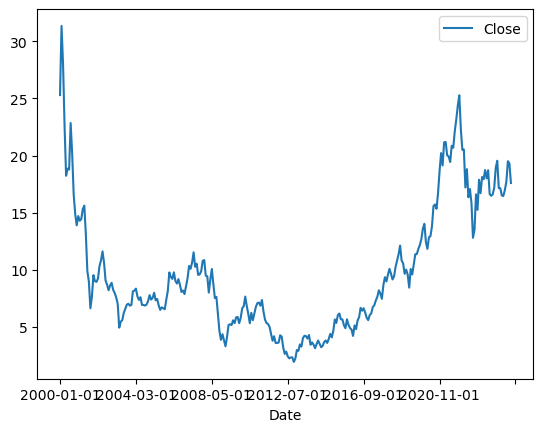

In [7]:
SONY_filtered.plot(y='Close', use_index='True')

In [8]:
SONY_filtered['Tomorrow'] = SONY_filtered['Close'].shift(-1)
SONY_filtered['Target'] = (SONY_filtered['Tomorrow'] > SONY_filtered['Close']).astype(int) # is tomorrows price greater than today

In [44]:
model0 = RandomForestClassifier(n_estimators=100, min_samples_split=7, max_depth = 10, random_state=31)

train0= SONY_filtered.iloc[:-60]
test0= SONY_filtered.iloc[-238:]

predictors = ['Close', 'Volume', 'High', 'Low']
target = 'Target'
model0.fit(train0[predictors], train0['Target'])

predictions = model0.predict(test0[predictors])
predictions = pd.Series(predictions, index=test0.index)
accuracy = accuracy_score(test0[target], predictions)
print(f'Accuracy: {accuracy}')

precision = precision_score(test0['Target'], predictions)
print(f'Precision Score: {precision}')

tree = model0.estimators_[0]

def getMaxDepth(tree):
    return tree.get_depth()


Accuracy: 0.8571428571428571
Precision Score: 0.9345794392523364


In [10]:
threshold = 0.5  
train0.loc[:, 'Target'] = (train0['Target'] > threshold).astype(int)
test0.loc[:, 'Target'] = (test0['Target'] > threshold).astype(int)

train_encoded = pd.get_dummies(train0.drop('Target', axis=1))
test_encoded = pd.get_dummies(test0.drop('Target', axis=1))

train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)
 
paramGrid = {
    'n_estimators': [100, 200, 300, 400, 500, 700, 1000],
    'min_samples_split': [2, 5, 10, 20],
    'max_depth': [None, 10, 20, 30]
    }

gridSearch = GridSearchCV(estimator=model0, param_grid=paramGrid, cv=5, n_jobs=-1, scoring='accuracy')
gridSearch.fit(train_encoded, train0['Target'])

print(f"Optimal n_estimators: {gridSearch.best_params_['n_estimators']}")
print(f"Optimal min_samples_split: {gridSearch.best_params_['min_samples_split']}")
print(f"Optimal max_depth: {gridSearch.best_params_['max_depth']}")

optimalNEstimators = gridSearch.best_params_['n_estimators']
optimalMinSamplesSplit = gridSearch.best_params_['min_samples_split']
optimalMaxDepth = gridSearch.best_params_['max_depth'].


Optimal n_estimators: 1000
Optimal min_samples_split: 2
Optimal max_depth: None


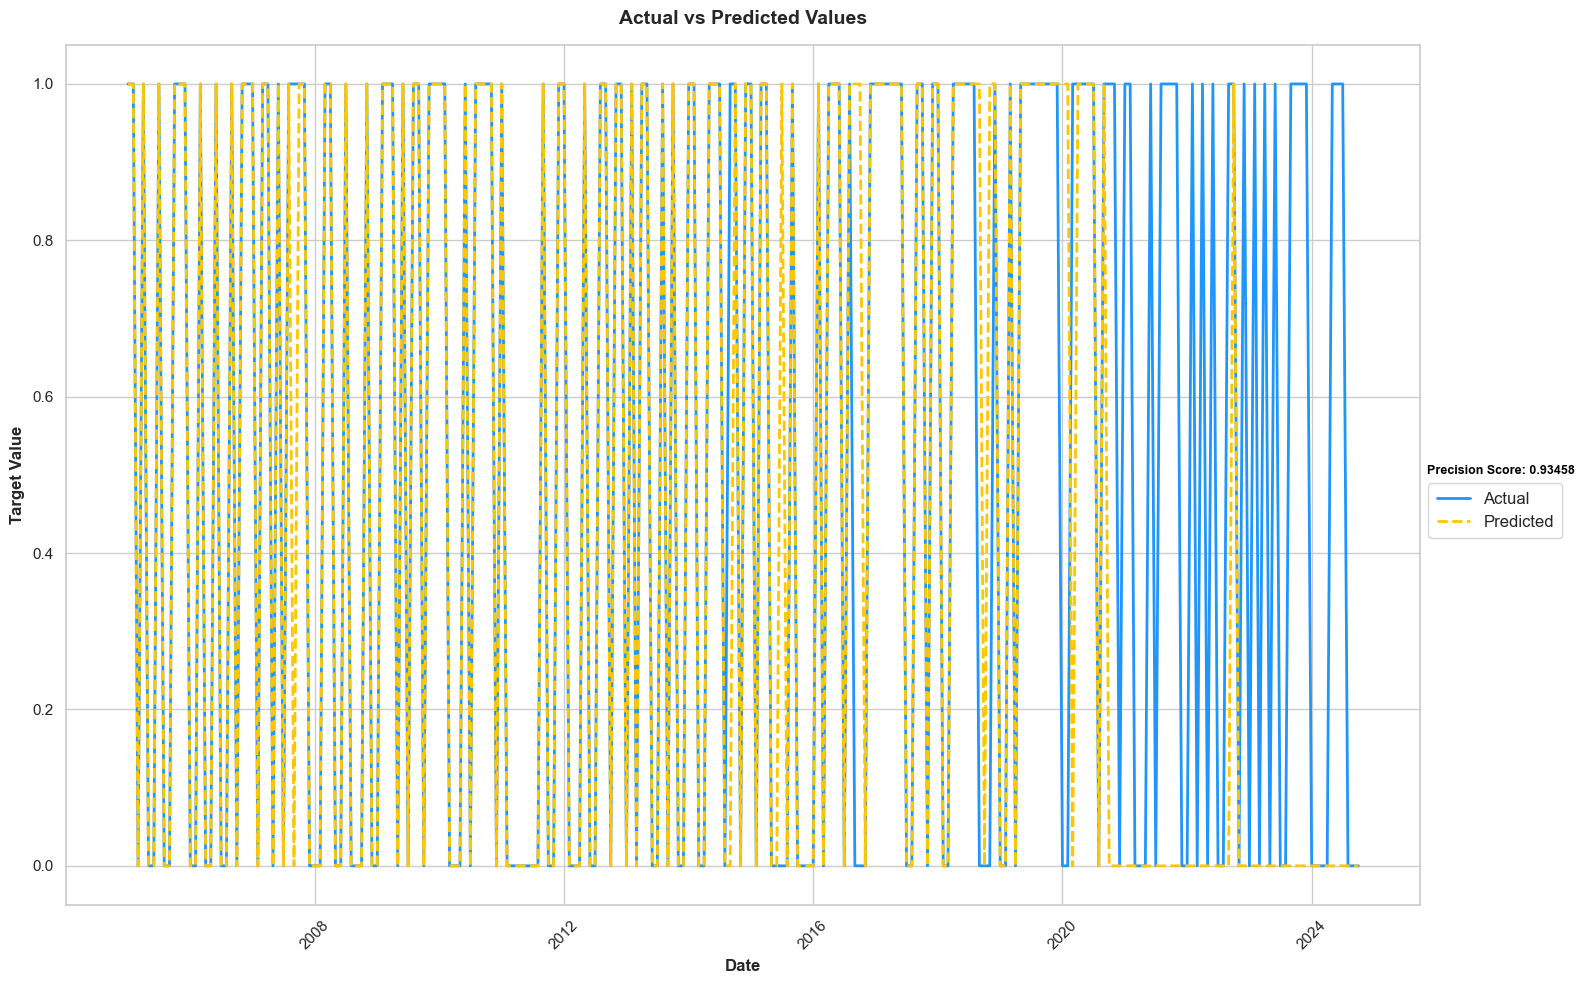

In [11]:
combinedValues = pd.concat([test0['Target'], predictions], axis=1)
combinedValues.columns = ['Actual', 'Predicted'] 
combinedValues.index = pd.to_datetime(combinedValues.index)

sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

plt.plot(combinedValues.index, combinedValues['Actual'], label='Actual', color='#1E96FC', linewidth=2)
plt.plot(combinedValues.index, combinedValues['Predicted'], label='Predicted', color='#FFC600', linewidth=2, linestyle='--')

plt.xlabel('Date', fontsize=12, labelpad=5, weight='bold')
plt.ylabel('Target Value', fontsize=12, labelpad=5, weight='bold')
plt.title('Actual vs Predicted Values',weight='bold', fontsize=14, pad=15)
plt.legend(fontsize=12, bbox_to_anchor=(1,0.5), borderpad=.5)
plt.text(1.005, 0.505, f'Precision Score: {precision:.5f}', ha='left', va='center', transform=plt.gca().transAxes, fontsize=9, color='black', weight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('GRAPHS/Actual VS Predicted Values for Model0.png', dpi=300)
plt.show()

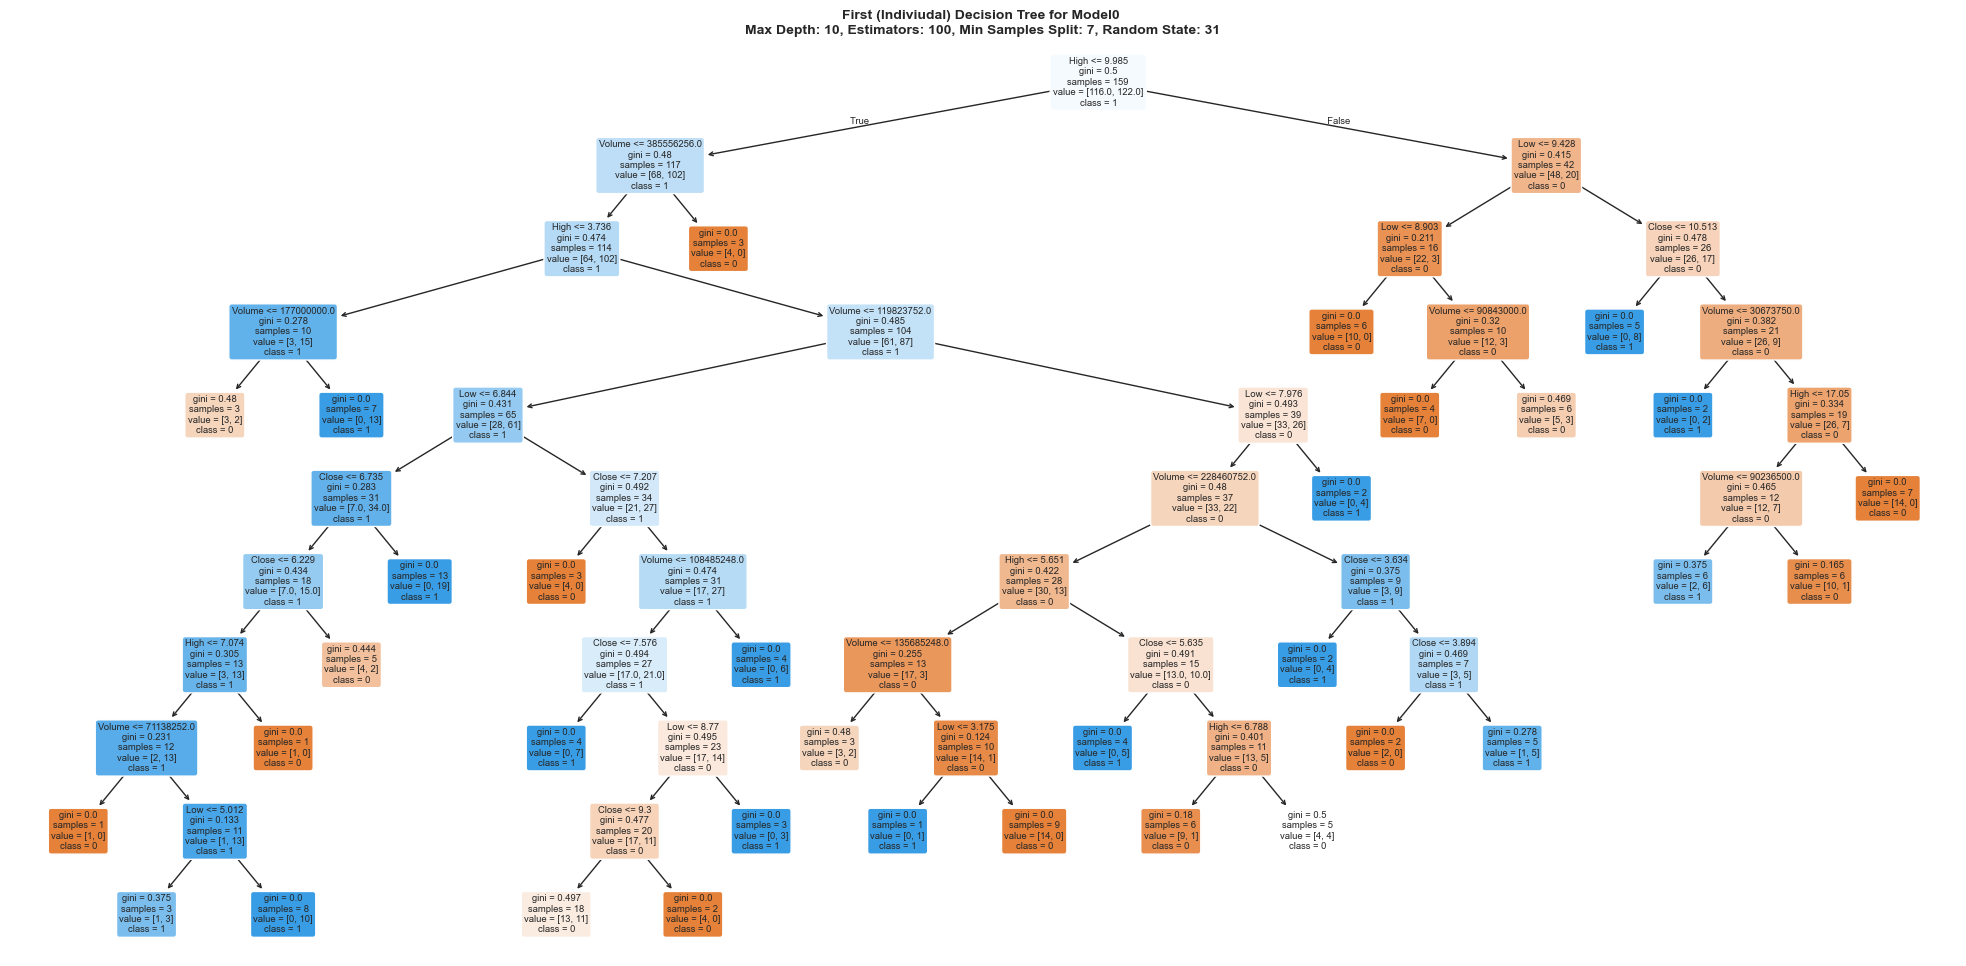

In [12]:
max_depth = getMaxDepth(tree)

title = f'First (Indiviudal) Decision Tree for Model0 \nMax Depth: {max_depth}, Estimators: {model0.n_estimators}, Min Samples Split: {model0.min_samples_split}, Random State: {model0.random_state}'

sns.set_context("notebook", font_scale=1.5)  
plt.figure(figsize=(20, 10))  
plot_tree(model0.estimators_[0], 
          filled=True, 
          feature_names=predictors, 
          class_names=model0.classes_.astype(str), 
          rounded=True)
plt.title(title, fontsize=10, weight='bold', pad=5)
plt.tight_layout()
plt.savefig('VISUALISATIONS/First Decision Tree for SONY (Model0).png', dpi=300)
plt.show()


In [22]:
features = []
filenames = []
modelPredict =[]

currentDateTime = datetime.now().isoformat().replace(":", "_")
checkpointFile = f'CHECKPOINTS/checkpointModel_{currentDateTime}.pkl'

def saveProgress(features, filenames, modelPredict, i, totalLength):
    percentage = (i / totalLength) * 100
    with open(checkpointFile, 'wb') as f:
        pickle.dump({'features': features, 'filenames': filenames, 'modelPredict': modelPredict}, f)
    print(f"Progress saved: {percentage:.3f}%")

def loadProgress():
    if os.path.exists(checkpointFile):
        with open(checkpointFile, 'rb') as f:
            checkpoint = pickle.load(f)
        return checkpoint['features'], checkpoint['filenames'], checkpoint['modelPredict']
    else:
        return [], [], []

features, filenames, modelPredict = loadProgress()


In [23]:
model = RandomForestClassifier(n_estimators=optimalNEstimators, min_samples_split=optimalMinSamplesSplit, max_depth = optimalMaxDepth, random_state=31)

def predict(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name='Predictions')
    combinedVals = pd.concat([test['Target'], preds], axis=1)
    return combinedVals

def backtest(data, model, predictors, saveInterval):
    allPredictions = []  
    totalLength = len(data) - 60
    startIndex = len(filenames)
    
    for i in tqdm(range(startIndex, len(data) - 60), desc="Backtesting Progress", unit="iteration"): 
        train = data.iloc[:i+60] 
        test = data.iloc[i+60:i+61]  
        
        predictions = predict(train, test, predictors, model)
        if predictions is not None and not predictions.empty:
            allPredictions.append(predictions)  # Append valid predictions

            features.append(predictions['Target'].values)
            filenames.append(test.index[0])
            modelPredict.append(predictions['Predictions'].values)
            if (i + 1 ) % saveInterval == 0:
                saveProgress(features, filenames, modelPredict, i, totalLength)
        else:
            print(f"Skipping prediction for index {i}, no valid predictions.")
    
    if not allPredictions:
        print("No predictions generated. Returning empty DataFrame.")
        return pd.DataFrame()  
    
    return pd.concat(allPredictions)

predictions = backtest(SONY_filtered, model, predictors, saveInterval=25)

Backtesting Progress:   0%|          | 0/238 [00:00<?, ?iteration/s]

Progress saved: 10.084%
Progress saved: 20.588%
Progress saved: 31.092%
Progress saved: 41.597%
Progress saved: 52.101%
Progress saved: 62.605%
Progress saved: 73.109%
Progress saved: 83.613%
Progress saved: 94.118%


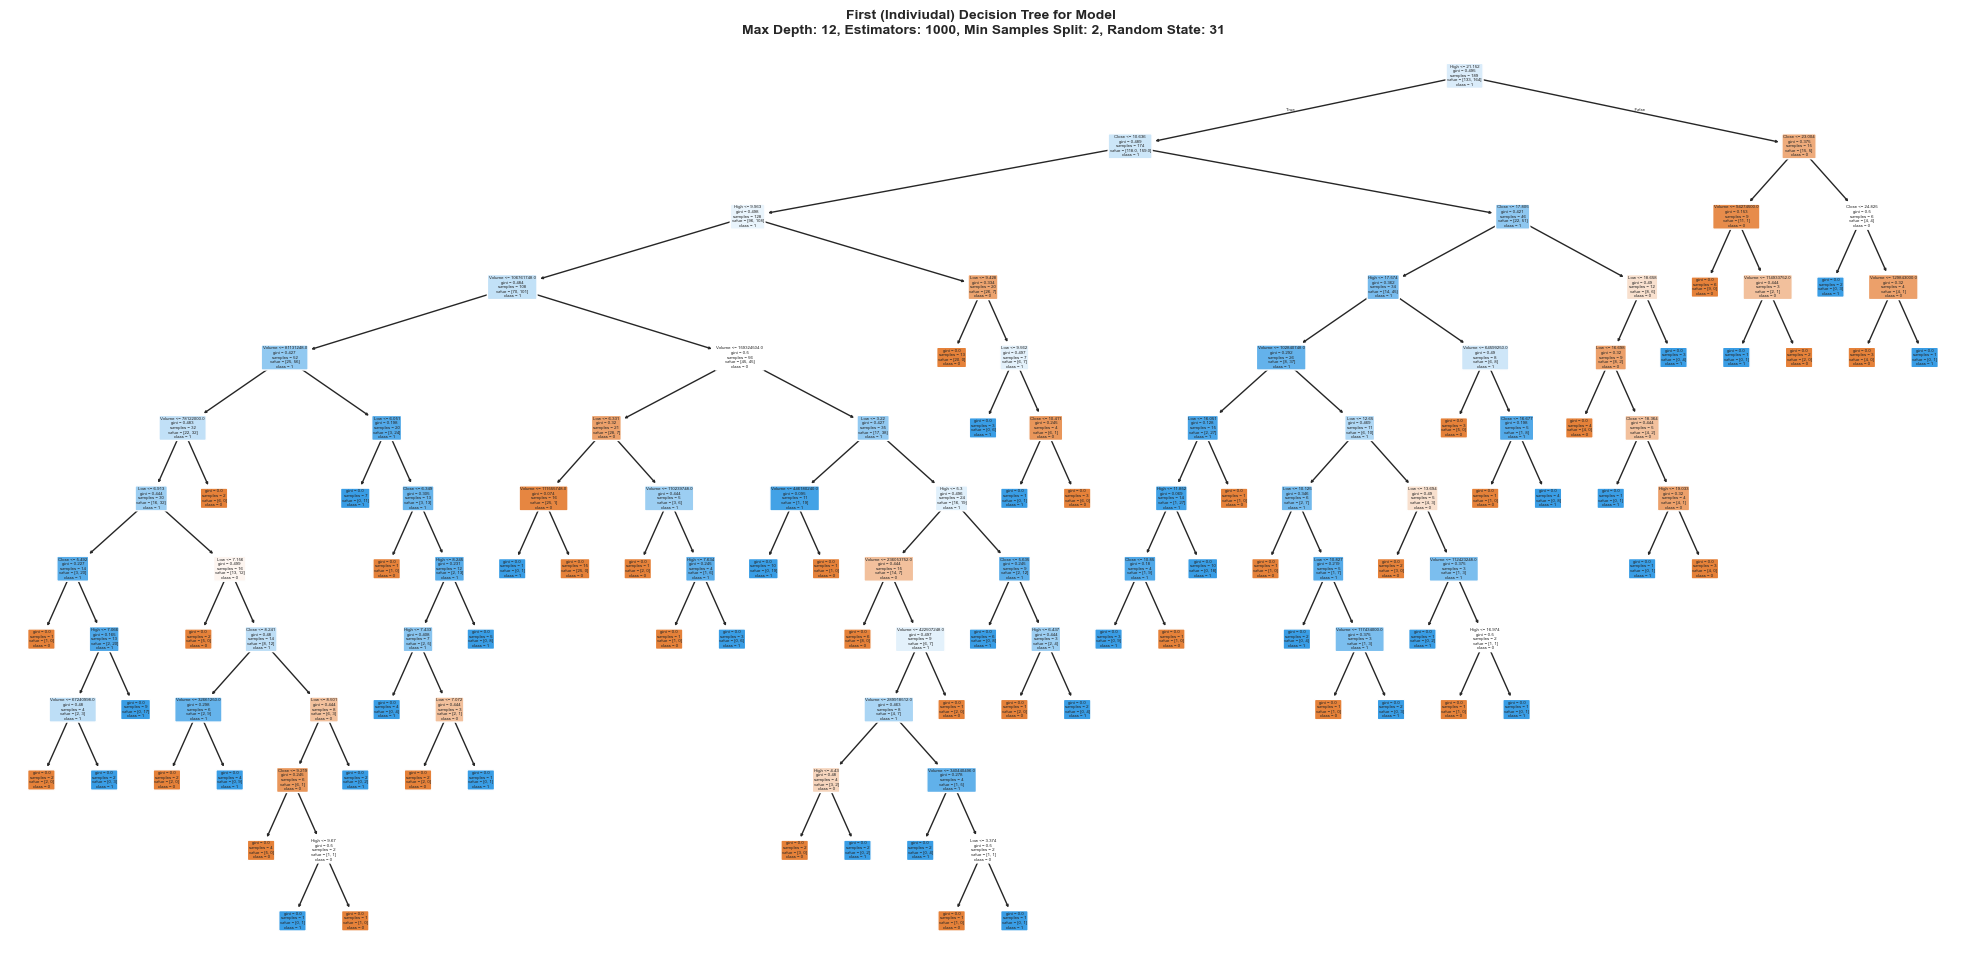

In [24]:
tree1 = model.estimators_[0]
max_depth = getMaxDepth(tree1)

title = f'First (Indiviudal) Decision Tree for Model \nMax Depth: {max_depth}, Estimators: {model.n_estimators}, Min Samples Split: {model.min_samples_split}, Random State: {model.random_state}'

sns.set_context("notebook", font_scale=1.5)  
plt.figure(figsize=(20, 10))  
plot_tree(model.estimators_[0], 
          filled=True, 
          feature_names=predictors, 
          class_names=model.classes_.astype(str), 
          rounded=True)
plt.title(title, fontsize=10, weight='bold', pad=5)
plt.tight_layout()
plt.savefig('VISUALISATIONS/First Decision Tree for SONY (Model).png', dpi=300)
plt.show()

In [25]:
predictions['Predictions'].value_counts() #count number of predictions (0 = down, 1 = up)

Predictions
1    122
0    116
Name: count, dtype: int64

In [26]:
SONYPrecisionScore = precision_score(predictions["Target"], predictions["Predictions"])
SONYBenchmark = predictions['Target'].value_counts() / predictions.shape[0] #benchmark for precision score comparision 
print(f'SONY Precision Score = {SONYPrecisionScore}')
print(f'SONY Benchmark Data: \n{SONYBenchmark}')

SONY Precision Score = 0.5
SONY Benchmark Data: 
Target
1    0.533613
0    0.466387
Name: count, dtype: float64


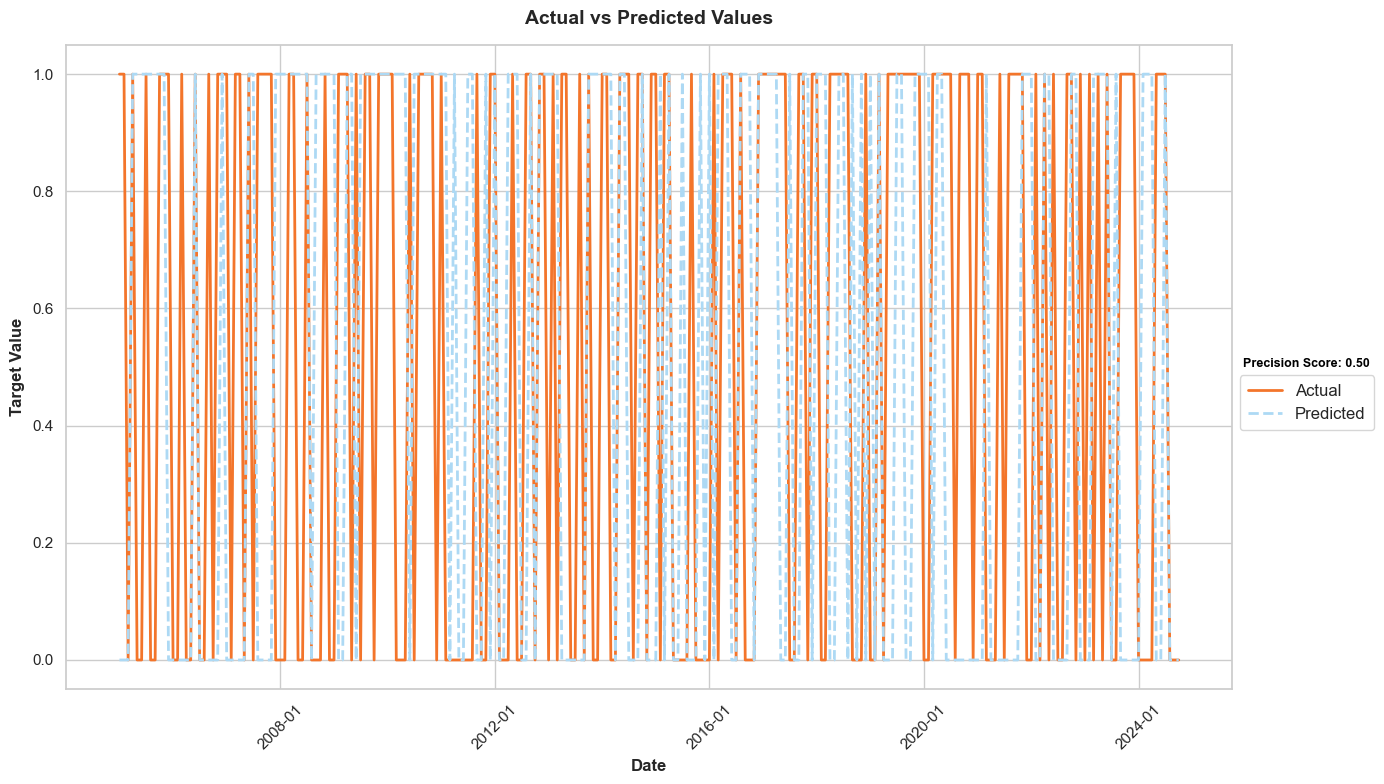

In [27]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

if not predictions.empty:
    predictions.index = pd.to_datetime(predictions.index)
    plt.plot(predictions.index, predictions['Target'], label='Actual', color='#F3752B', linewidth=2)
    plt.plot(predictions.index, predictions['Predictions'], label='Predicted', color='#ADD9F4', linewidth=2, linestyle='--')
    plt.xlabel('Date', fontsize=12, labelpad=5, weight='bold')
    plt.ylabel('Target Value', fontsize=12, labelpad=5, weight='bold')
    plt.title('Actual vs Predicted Values', weight='bold', fontsize=14, pad=15)
    plt.legend(fontsize=12, bbox_to_anchor=(1,0.5), borderpad=.5)
    plt.text(1.010, 0.505, f'Precision Score: {SONYPrecisionScore:.2f}', ha='left', va='center', transform=plt.gca().transAxes, fontsize=9, color='black', weight='bold')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  
    plt.xticks(rotation=45)    
    plt.tight_layout()
    plt.savefig('GRAPHS/Actual VS Predicted Values for Model.png', dpi=300)
    plt.show()
else:
    print("No data to plot.")

In [28]:
SONY_filtered['Target'] = SONY_filtered['Target'].astype('float64')
SONY_filtered['Close'] = pd.to_numeric(SONY_filtered['Close'], errors='coerce')
SONY_filtered['Target'] = pd.to_numeric(SONY_filtered['Target'], errors='coerce')
SONY_filtered.dropna(subset=['Close', 'Target'], inplace=True)
SONY_filtered.fillna(0, inplace=True)

print(SONY_filtered.dtypes)

Company           object
Ticker_Symbol     object
Currency          object
Open             float64
High             float64
Low              float64
Close            float64
Adj_Close        float64
Volume             int64
Tomorrow         float64
Target           float64
dtype: object


In [29]:
SONY_filtered1 = SONY_filtered.select_dtypes(include=['float64', 'int64'])
horizons = [1,3,12,48] #for rolling means (, 3months, year)

newPredictors = []
for horizon in horizons:
    rollingAverage = SONY_filtered1.rolling(horizon).mean()
    
    ratioColumn = f'Close_Ratio_{horizon}'
    SONY_filtered1[ratioColumn] = SONY_filtered1['Close'] / rollingAverage['Close']
    
    trendColumn = f'Trend_{horizon}'
    SONY_filtered1[trendColumn] = SONY_filtered1.shift(1).rolling(horizon).sum()['Target']
    
    newPredictors += [ratioColumn, trendColumn]

In [30]:
SONY_filtered1.fillna(0, inplace=True)
SONY_filtered1

,Open,High,Low,Close,Adj_Close,Volume,Tomorrow,Target,Close_Ratio_1,Trend_1,Close_Ratio_3,Trend_3,Close_Ratio_12,Trend_12,Close_Ratio_48,Trend_48
Date,,,,,,,,,,,,,,,,
2000-01-01,28.525000,29.168751,20.850000,25.299999,14.535083,147012000,31.350000,1.0,1.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2000-02-01,25.293751,31.475000,25.000000,31.350000,18.010864,67437000,28.012501,0.0,1.0,1.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2000-03-01,30.100000,31.299999,21.700001,28.012501,16.093437,112674000,22.562500,0.0,1.0,0.0,0.992618,0.0,0.000000,0.0,0.000000,0.0
2000-04-01,28.250000,28.250000,22.312500,22.562500,12.974537,74071000,18.237499,0.0,1.0,0.0,0.826213,1.0,0.000000,0.0,0.000000,0.0
2000-05-01,22.700001,23.481251,17.750000,18.237499,10.487453,65035500,18.862499,1.0,1.0,0.0,0.795095,0.0,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-01,16.625999,17.497999,15.860000,16.990000,16.990000,83581000,17.718000,1.0,1.0,1.0,1.019971,1.0,0.978264,6.0,0.924238,26.0
2024-07-01,17.024000,19.294001,17.004000,17.718000,17.718000,90385000,19.511999,1.0,1.0,1.0,1.038651,2.0,1.025110,6.0,0.961524,26.0
2024-08-01,17.346001,19.544001,15.956000,19.511999,19.511999,90948500,19.313999,0.0,1.0,1.0,1.079602,3.0,1.113476,7.0,1.054370,26.0


In [31]:
features1 = []
filenames1 = []
modelPredict1 = []

checkpointFile = f'CHECKPOINTS/checkpointModelNew_{currentDateTime}.pkl'

def saveProgress1(features1, filenames1, modelPredict1, i, totalLength1):
    percentage = (i / totalLength1) * 100
    with open(checkpointFile, 'wb') as f:
        pickle.dump({'features': features1, 'filenames': filenames1, 'modelPredict': modelPredict1}, f)
    print(f"Progress saved: {percentage:.3f}%")

def loadProgress1():
    if os.path.exists(checkpointFile):
        with open(checkpointFile, 'rb') as f:
            checkpoint = pickle.load(f)
        return checkpoint['features'], checkpoint['filenames'], checkpoint['modelPredict']
    else:
        return [], [], []

features1, filenames1, modelPredict1 = loadProgress1()

modelNew = RandomForestClassifier(n_estimators=optimalNEstimators, min_samples_split=optimalMinSamplesSplit, max_depth=optimalMaxDepth, random_state=31)

def predict1(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])  
    preds = model.predict_proba(test[predictors])[:, 1] 
    preds[preds >= 0.6] = 1  #threshold for prediction
    preds[preds < 0.6] = 0
    preds = pd.Series(preds, index=test.index, name='Predictions')
    
    combinedVals = pd.concat([test['Target'], preds], axis=1)
    return combinedVals

def backtest1(data, predict1, predictors, modelNew, saveInterval):
    allPredictions = []  #store combined predictions
    totalLength1 = len(data) - 60
    startIndex = len(filenames1)  
    
    for i in tqdm(range(startIndex, len(data) - 60), desc="Backtesting Progress", unit="iteration"): 
        train = data.iloc[:i+60] 
        test = data.iloc[i+60:i+61] 
        
        predictions = predict1(train, test, predictors, modelNew)
        if predictions is not None and not predictions.empty:
            allPredictions.append(predictions) 
            
            features1.append(predictions['Target'].values)
            filenames1.append(test.index[0])
            modelPredict1.append(predictions['Predictions'].values)
            
            if (i + 1) % saveInterval == 0:
                saveProgress1(features, filenames1, modelPredict1, i, totalLength1)
        else:
            print(f"Skipping prediction for index {i}, no valid predictions.")
    
    if not allPredictions:
        print("No predictions generated. Returning empty DataFrame.")
        return pd.DataFrame()  
    
    return pd.concat(allPredictions)

newPredictions = backtest1(SONY_filtered1, predict1, newPredictors, modelNew, saveInterval=25)

Backtesting Progress:   0%|          | 0/238 [00:00<?, ?iteration/s]

Progress saved: 10.084%
Progress saved: 20.588%
Progress saved: 31.092%
Progress saved: 41.597%
Progress saved: 52.101%
Progress saved: 62.605%
Progress saved: 73.109%
Progress saved: 83.613%
Progress saved: 94.118%


IndexError: list index out of range

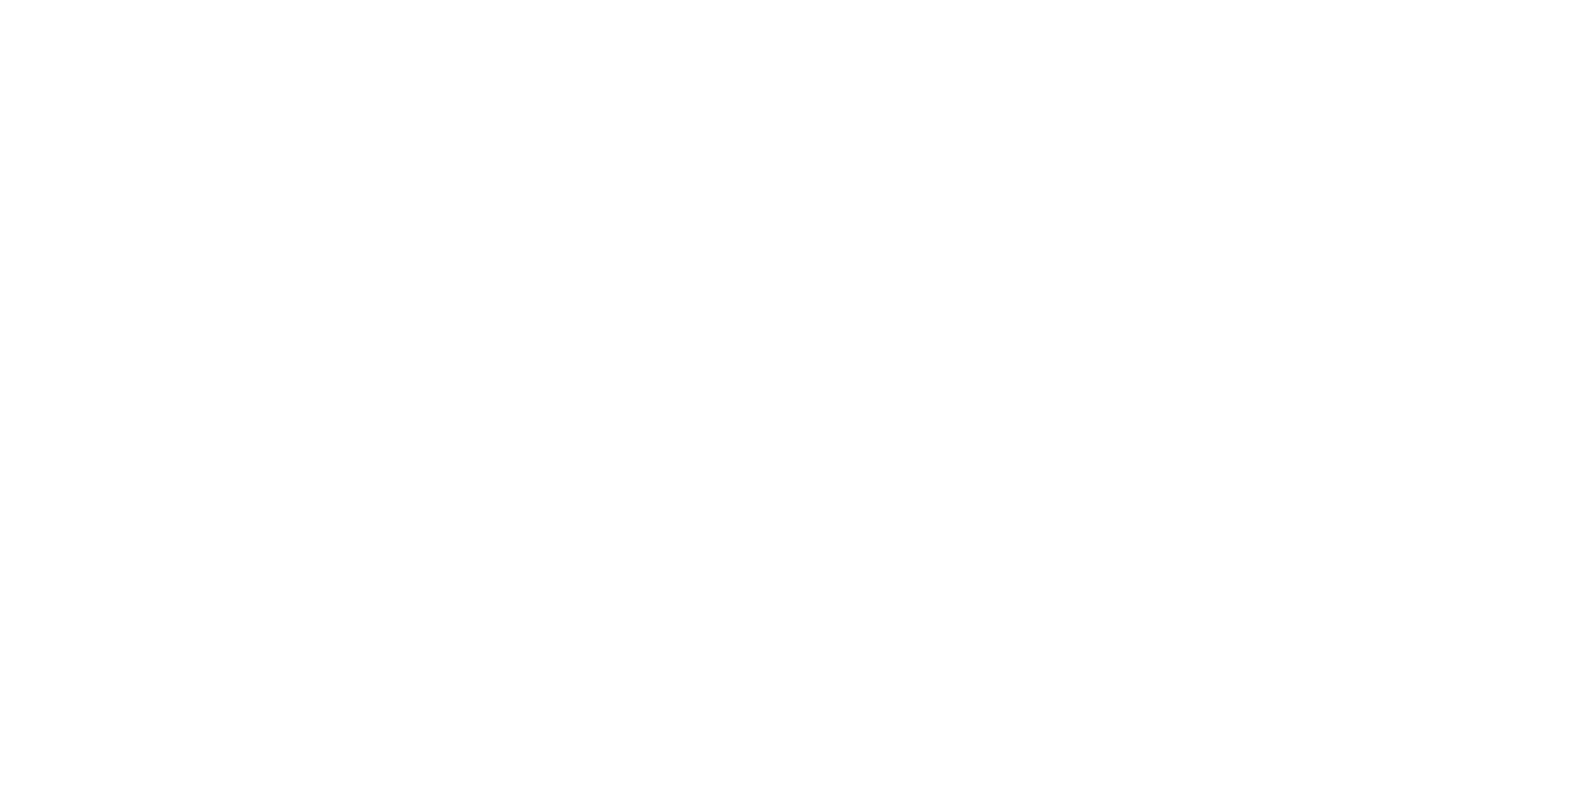

In [50]:
tree2 = modelNew.estimators_[0]
max_depth = getMaxDepth(tree2)

title = f'First (Indiviudal) Decision Tree for Model \nMax Depth: {max_depth}, Estimators: {modelNew.n_estimators}, Min Samples Split: {modelNew.min_samples_split}, Random State: {modelNew.random_state}'

sns.set_context("notebook", font_scale=1.5)  
plt.figure(figsize=(20, 10))  
plot_tree(modelNew.estimators_[0], 
          filled=True, 
          feature_names=predictors, 
          class_names=modelNew.classes_.astype(str), 
          rounded=True)
plt.title(title, fontsize=10, weight='bold', pad=5)
plt.tight_layout()
plt.savefig('VISUALISATIONS/First Decision Tree for SONY (Model1).png', dpi=300)
plt.show()

In [35]:
newPredictions['Predictions'].value_counts()

Predictions
0.0    162
1.0     76
Name: count, dtype: int64

In [36]:
SONYPrecisionScoreNew = precision_score(newPredictions["Target"], newPredictions["Predictions"])
SONYBenchmarkNew = newPredictions['Target'].value_counts() / newPredictions.shape[0] #benchmark for precision score comparision 
print(f'SONY Precision Score = {SONYPrecisionScoreNew}')
print(f'SONY Benchmark Data: \n{SONYBenchmarkNew}')

SONY Precision Score = 0.4473684210526316
SONY Benchmark Data: 
Target
1.0    0.533613
0.0    0.466387
Name: count, dtype: float64


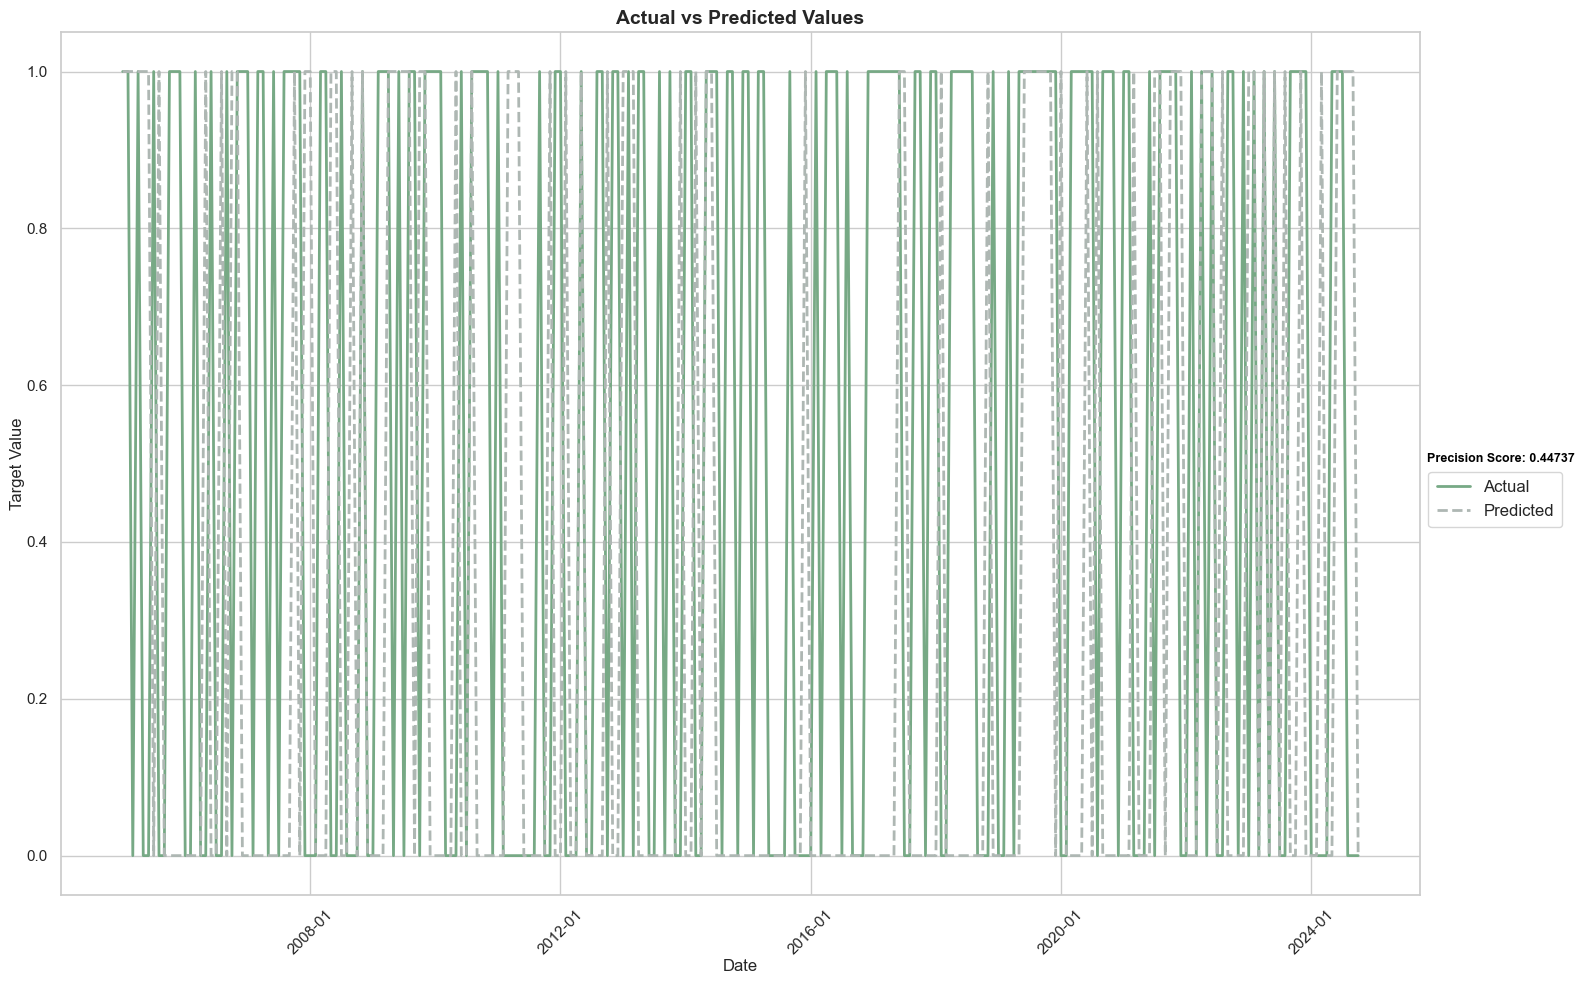

In [37]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

if not newPredictions.empty:
    newPredictions.index = pd.to_datetime(newPredictions.index)
    plt.plot(newPredictions.index, newPredictions['Target'], label='Actual', color='#77A985', linewidth=2)
    plt.plot(newPredictions.index, newPredictions['Predictions'], label='Predicted', color='#AEB7B3', linewidth=2, linestyle='--')
    plt.xlabel('Date', fontsize=12, labelpad=1)
    plt.ylabel('Target Value', fontsize=12, labelpad=1)
    plt.title('Actual vs Predicted Values', weight='bold', fontsize=14)
    plt.legend(fontsize=12, bbox_to_anchor=(1,0.5), borderpad=.5)
    plt.text(1.005, 0.505, f'Precision Score: {SONYPrecisionScoreNew:.5f}', ha='left', va='center', transform=plt.gca().transAxes, fontsize=9, color='black', weight='bold')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  
    plt.xticks(rotation=45)    
    plt.tight_layout()
    plt.savefig('GRAPHS/Actual VS Predicted Values for Model1.png', dpi=300)
    plt.show()
else:
    print("No data to plot.")